In [2]:
# =========================
# LOAD FINAL DATA
# =========================

import xarray as xr
import numpy as np

# Load data
ds_melt = xr.open_dataset(r"P:\snowmelt_stochastic_model\data\processed\melt_models.nc")
sigma = xr.open_dataarray(r"P:\snowmelt_stochastic_model\data\processed\sigma.nc")
ensemble = np.load(r"P:\snowmelt_stochastic_model\data\processed\monte_carlo_ensemble.npy")

melt_det = ds_melt["melt_det"]
time = melt_det["time"]

print("Data loaded for results")

Data loaded for results


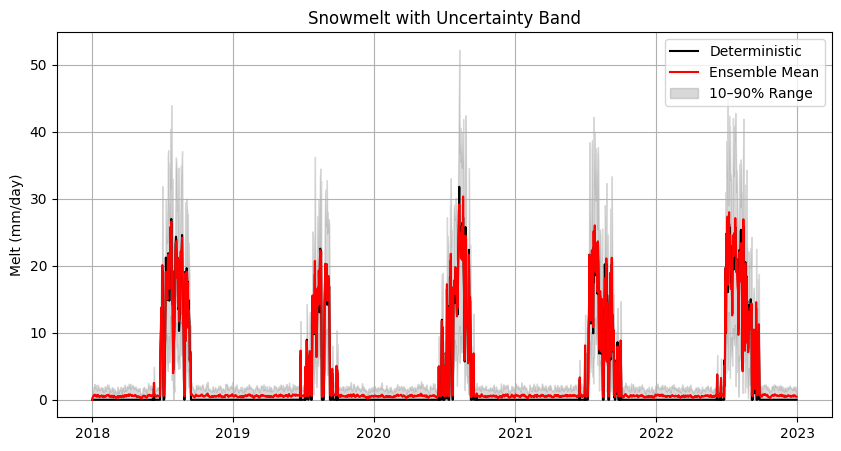

In [3]:
# =========================
# FIGURE 1 — UNCERTAINTY BAND
# =========================

import matplotlib.pyplot as plt

# Compute stats
p10 = np.percentile(ensemble, 10, axis=0)
p90 = np.percentile(ensemble, 90, axis=0)
mean_mc = np.mean(ensemble, axis=0)

plt.figure(figsize=(10,5))

plt.plot(time, melt_det, label="Deterministic", color='black', linewidth=1.5)
plt.plot(time, mean_mc, label="Ensemble Mean", color='red', linewidth=1.5)

plt.fill_between(
    time.values,
    p10,
    p90,
    color='gray',
    alpha=0.3,
    label="10–90% Range"
)

plt.title("Snowmelt with Uncertainty Band")
plt.ylabel("Melt (mm/day)")
plt.legend()
plt.grid()

plt.savefig(r"P:\snowmelt_stochastic_model\outputs\figures\figure_1_uncertainty.png", dpi=300)

plt.show()

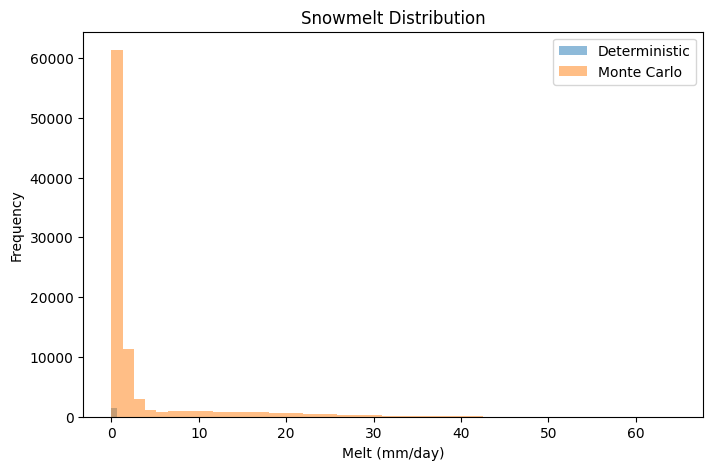

In [4]:
# =========================
# FIGURE 2 — DISTRIBUTION
# =========================

plt.figure(figsize=(8,5))

plt.hist(melt_det.values, bins=50, alpha=0.5, label="Deterministic")
plt.hist(ensemble.flatten(), bins=50, alpha=0.5, label="Monte Carlo")

plt.xlabel("Melt (mm/day)")
plt.ylabel("Frequency")
plt.title("Snowmelt Distribution")

plt.legend()

plt.savefig(r"P:\snowmelt_stochastic_model\outputs\figures\figure_2_distribution.png", dpi=300)

plt.show()

In [5]:
# =========================
# EXTREME VALUE ANALYSIS
# =========================

p95_det = np.percentile(melt_det, 95)
p95_mc = np.percentile(ensemble, 95)

p99_det = np.percentile(melt_det, 99)
p99_mc = np.percentile(ensemble, 99)

print("Deterministic P95:", p95_det)
print("Monte Carlo P95:", p95_mc)

print("Deterministic P99:", p99_det)
print("Monte Carlo P99:", p99_mc)

Deterministic P95: 19.44365
Monte Carlo P95: 20.495253886465875
Deterministic P99: 24.333908
Monte Carlo P99: 33.52317941849076


In [6]:
# =========================
# CLEAN STYLE (OPTIONAL)
# =========================

plt.style.use('seaborn-v0_8-darkgrid')

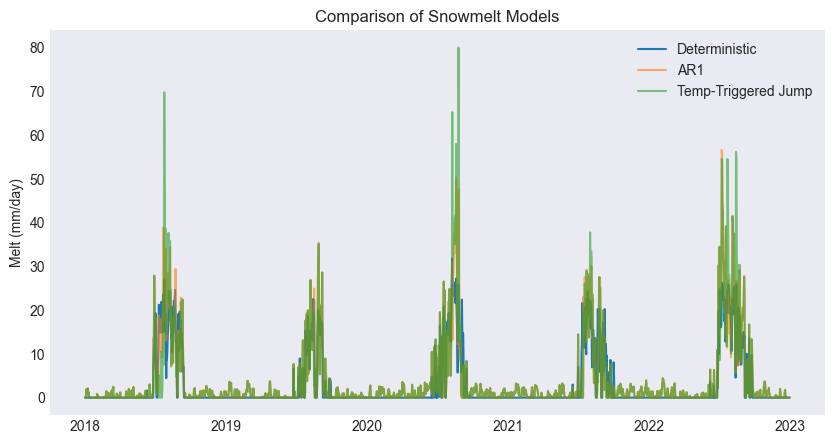

In [7]:
# =========================
# FIGURE — MODEL COMPARISON (OPTIONAL)
# =========================

melt_ar1 = ds_melt["melt_ar1"]
melt_jump = ds_melt["melt_temp_jump"]

plt.figure(figsize=(10,5))

plt.plot(time, melt_det, label="Deterministic", linewidth=1.5)
plt.plot(time, melt_ar1, label="AR1", alpha=0.6)
plt.plot(time, melt_jump, label="Temp-Triggered Jump", alpha=0.6)

plt.title("Comparison of Snowmelt Models")
plt.ylabel("Melt (mm/day)")
plt.legend()
plt.grid()

plt.savefig(r"P:\snowmelt_stochastic_model\outputs\figures\figure_model_comparison.png", dpi=300)

plt.show()

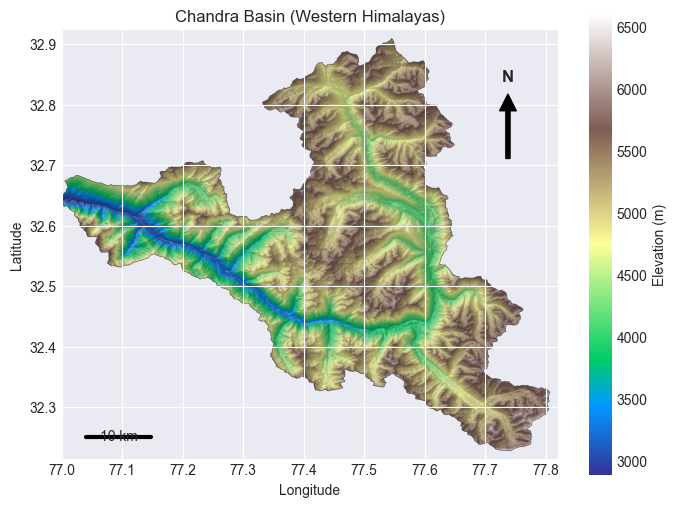

In [20]:
# =========================
# STUDY AREA MAP (FINAL CORRECTED)
# =========================

import rasterio
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LightSource

# -------------------------
# LOAD DEM
# -------------------------
with rasterio.open(r"P:\snowmelt_stochastic_model\data\raw\SRTM\n32_e077_1arc_v3.tif") as src:
    dem = src.read(1)
    bounds = src.bounds

# -------------------------
# LOAD BASIN
# -------------------------
with rasterio.open(r"P:\snowmelt_stochastic_model\data\processed\basin_mask.tif") as src:
    basin = src.read(1)

# -------------------------
# CLEAN DEM
# -------------------------
dem = dem.astype(float)
dem[(dem < 0) | (dem > 9000)] = np.nan

# -------------------------
# CLIP DEM
# -------------------------
dem_clipped = np.where(basin == 1, dem, np.nan)

# -------------------------
# CENTERING
# -------------------------
rows, cols = np.where(basin == 1)

pad = 50
min_row, max_row = max(rows.min()-pad,0), min(rows.max()+pad, dem.shape[0])
min_col, max_col = max(cols.min()-pad,0), min(cols.max()+pad, dem.shape[1])

dem_crop = dem_clipped[min_row:max_row, min_col:max_col]
basin_crop = basin[min_row:max_row, min_col:max_col]

# -------------------------
# EXTENT
# -------------------------
x_res = (bounds.right - bounds.left) / dem.shape[1]
y_res = (bounds.top - bounds.bottom) / dem.shape[0]

extent = [
    bounds.left + min_col * x_res,
    bounds.left + max_col * x_res,
    bounds.bottom + min_row * y_res,
    bounds.bottom + max_row * y_res
]

# -------------------------
# HILLSHADE
# -------------------------
ls = LightSource(azdeg=315, altdeg=45)
hillshade = ls.hillshade(dem_crop, vert_exag=1)

# -------------------------
# EDGE (boundary)
# -------------------------
edge = np.zeros_like(basin_crop)
edge[1:, :] |= (basin_crop[1:, :] != basin_crop[:-1, :])
edge[:, 1:] |= (basin_crop[:, 1:] != basin_crop[:, :-1])

edge_plot = np.where(edge, 0, np.nan)

# -------------------------
# PLOT
# -------------------------
fig, ax = plt.subplots(figsize=(8,6))

img = ax.imshow(
    dem_crop,
    cmap='terrain',
    extent=extent,
    origin='upper',
    vmin=np.nanmin(dem_crop),
    vmax=np.nanmax(dem_crop)
)

ax.imshow(
    hillshade,
    cmap='gray',
    extent=extent,
    origin='upper',
    alpha=0.3
)

ax.imshow(
    edge_plot,
    cmap='gray',
    extent=extent,
    origin='upper'
)

# -------------------------
# NORTH ARROW (FIXED)
# -------------------------
ax.annotate(
    '',
    xy=(0.9, 0.85),      # arrow tip (UP)
    xytext=(0.9, 0.7),   # base
    arrowprops=dict(facecolor='black', width=3, headwidth=12),
    xycoords='axes fraction'
)

ax.text(
    0.9, 0.88,
    'N',
    transform=ax.transAxes,
    ha='center',
    fontsize=12,
    fontweight='bold'
)

# -------------------------
# SCALE BAR (CORRECTED)
# -------------------------
mean_lat = (extent[2] + extent[3]) / 2

# longitude degree to km conversion
km_per_deg = 111 * np.cos(np.deg2rad(mean_lat))

scale_km = 10
scale_deg = scale_km / km_per_deg

x_start = extent[0] + 0.05 * (extent[1] - extent[0])
y_start = extent[2] + 0.05 * (extent[3] - extent[2])

ax.plot(
    [x_start, x_start + scale_deg],
    [y_start, y_start],
    color='black',
    linewidth=3
)

ax.text(
    x_start + scale_deg/2,
    y_start - 0.005,
    f'{scale_km} km',
    ha='center',
    fontsize=10
)

# -------------------------
# LABELS
# -------------------------
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

# -------------------------
# COLORBAR
# -------------------------
cbar = plt.colorbar(img, ax=ax)
cbar.set_label("Elevation (m)")

# -------------------------
# TITLE
# -------------------------
ax.set_title("Chandra Basin (Western Himalayas)")

# -------------------------
# SAVE
# -------------------------
plt.savefig(
    r"P:\snowmelt_stochastic_model\outputs\figures\figure_study_area_final.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

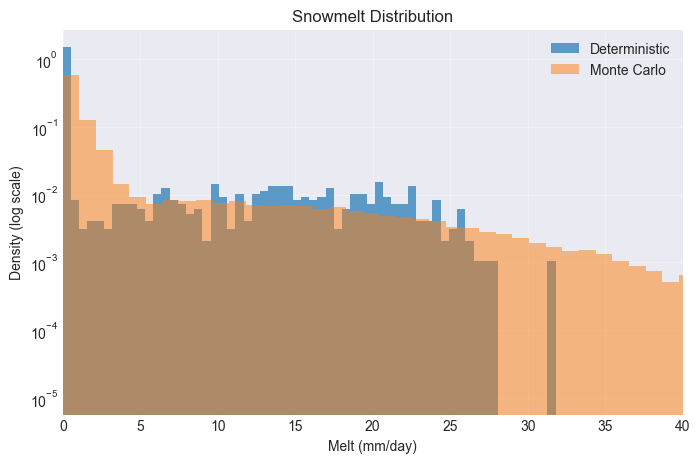

In [22]:
# =========================
# FINAL DISTRIBUTION FIGURE (PUBLICATION READY)
# =========================

import matplotlib.pyplot as plt
import numpy as np

# Flatten data
det = melt_det.values.flatten()
mc = ensemble.flatten()

plt.figure(figsize=(8,5))

# Histograms (density for fair comparison)
plt.hist(det,
         bins=60,
         density=True,
         alpha=0.7,
         label="Deterministic")

plt.hist(mc,
         bins=60,
         density=True,
         alpha=0.5,
         label="Monte Carlo")

# Log scale to highlight extremes
plt.yscale('log')

# Focus range (removes empty tail noise)
plt.xlim(0, 40)

# Labels
plt.xlabel("Melt (mm/day)")
plt.ylabel("Density (log scale)")
plt.title("Snowmelt Distribution")

plt.legend()
plt.grid(True, alpha=0.3)

# Save
plt.savefig(
    r"P:\snowmelt_stochastic_model\outputs\figures\figure_2_distribution.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()